# 2025-26 Points per Win

## Introduction

The concept is simple, score the most points and you win the game. But when NBA teams win games, do they score more than their average or do some teams have to reduce thier offensive output and focus on other aspects of the game in order to win? If a team is really good, then the assumption is that they likely blow away most competition with high scoring basketball. Perhaps it may be the other around, poorer teams may need to cultivate more effort than normal to pull out a win. But is that method sustainable?

In [112]:
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.pyplot import Axes
import os
from PIL import Image
from pathlib import Path
import numpy as np

csv_dir = 'csvs'

# Pull data from the 2025-2026 NBA season
games_26 = leaguegamefinder.LeagueGameFinder(season_nullable='2025-26', season_type_nullable='Regular Season')
# get data frame from returned list
df_26: pd.DataFrame = games_26.get_data_frames()[0]
# Write data to csv for easier viewing. Not necessary
df_26.to_csv(os.path.join(csv_dir,'25_26_season_raw_data.csv') ,index=False)

In [113]:
# 2025-26
team_stats_26 = df_26[['SEASON_ID','TEAM_ABBREVIATION', 'PTS', 'WL']]
# Change Season ID Value
team_stats_26['SEASON_ID'] = '2025-26'
# Write to csv for easy viewing
team_stats_26.to_csv(os.path.join(csv_dir,'26_season_filtered_points.csv'), index=False)

In [114]:
# Aggregating Game data based off of the game ID
game_stats = df_26[['TEAM_ABBREVIATION', 'GAME_ID', 'MATCHUP' , 'WL', 'PTS' ]]
# New Names
name_dict = {
    'TEAM_ABBREVIATION': 'team',
    'GAME_ID': 'gameid',
    'MATCHUP': 'opp',
    'PTS': 'points',
}
game_stats = game_stats.rename(columns=name_dict)
game_stats['home/away'] = game_stats["opp"].apply(lambda x: "away" if "@" in x else "home")
game_stats['opp'] = game_stats['opp'].str[-3:]

def opp_score(x,y):

    score: int = game_stats['points'].loc[(game_stats['team']== x) & (game_stats['gameid']==y)].values[0]

    return score

game_stats['opp_score'] = game_stats.apply(lambda x: opp_score(x['opp'], x['gameid']), axis = 1)
print(game_stats.head())

  team      gameid  opp WL  points home/away  opp_score
0  CHI  0022501193  DAL  L     128      away        149
1  BKN  0022501192  TOR  L     101      away        136
2  PHX  0022501196  OKC  W     135      away        103
3  OKC  0022501196  PHX  L     103      home        135
4  MEM  0022501194  HOU  L     101      away        132


In [115]:
# Repeating the same steps performed previously, but for the 2025-26 season.
overall_avg = (
    team_stats_26.groupby('TEAM_ABBREVIATION')
    .agg(
        points=('PTS', 'mean'),
    )
).reset_index()

overall_avg.to_csv(os.path.join(csv_dir,'overall_avg.csv'), index=False)

# Filter Data frame for just the wins of each team
wins_data = team_stats_26[team_stats_26['WL'] == 'W']
# wins_data.to_csv(os.path.join(csv_dir,'wins_raw.csv'), index=False)
# print(wins_data.head())

league_win_avg = sum(wins_data['PTS'])/len(wins_data['PTS'])

print(league_win_avg)
# Aggregate the Wins Data
wins_agg = (
    wins_data.groupby('TEAM_ABBREVIATION')
    .agg(
        points=('PTS', 'mean'),
        wins=('WL', lambda s: (s=='W').sum())
    )
).reset_index()
wins_agg = wins_agg.rename(columns={'TEAM_ABBREVIATION':'teams'})
print(wins_agg.head())
wins_agg.to_csv(os.path.join(csv_dir,'wins_avg.csv'), index=False)

122.24471544715448
  teams      points  wins
0   ATL  123.521739    46
1   BKN  116.300000    20
2   BOS  120.446429    56
3   CHA  121.795455    44
4   CHI  125.000000    31


In [116]:
win_merge = wins_agg.rename(columns={'points':'win_points'})
ovr_merge = overall_avg.rename(columns={'points':'ovr_points', 'TEAM_ABBREVIATION':'teams'})
points_compare = pd.merge(win_merge, ovr_merge, how='inner', on=['teams'])
points_compare['p_diff'] = points_compare['win_points'] - points_compare['ovr_points']
points_compare['win_pct'] = round(points_compare['wins']/82,3)
points_compare = points_compare.sort_values('p_diff', ascending=True)
print(points_compare.head())

   teams  win_points  wins  ovr_points    p_diff  win_pct
10   HOU  118.307692    52  115.231707  3.075985    0.634
26   SAS  122.951613    62  119.829268  3.122345    0.756
7    DEN  125.296296    54  122.073171  3.223126    0.659
20   OKC  122.265625    64  119.024390  3.241235    0.780
8    DET  121.150000    60  117.768293  3.381707    0.732


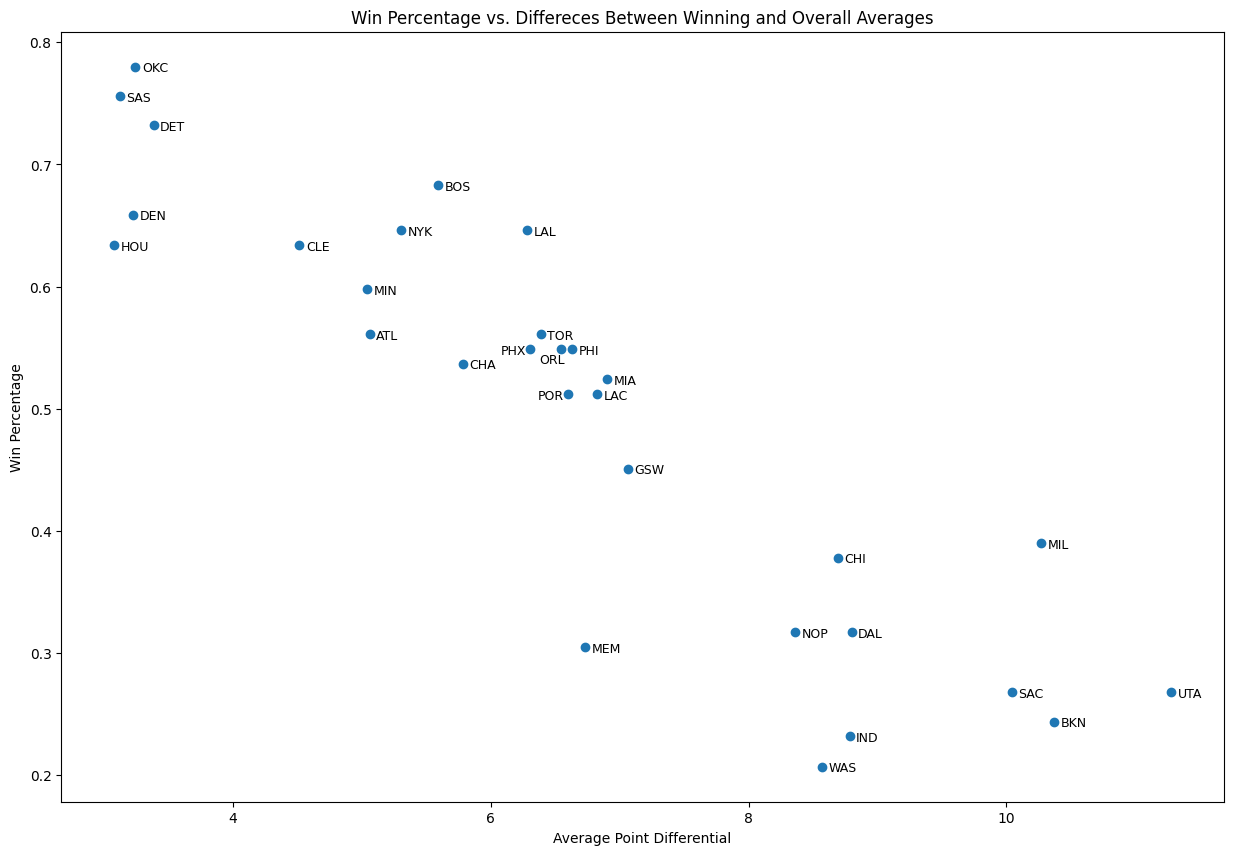

In [117]:
labels = list(points_compare['teams'])
p_diff = list(points_compare['p_diff'])
win_pct = list(points_compare['win_pct'])
#print(labels)
fig4, ax4 = plt.subplots(figsize =(15,10))
# plt.scatter(points_compare['win_pct'], points_compare['p_diff'])
plt.scatter(p_diff, win_pct)
plt.title('Win Percentage vs. Differeces Between Winning and Overall Averages')
ax4.set_ylabel("Win Percentage")
ax4.set_xlabel("Average Point Differential")

for i, label in enumerate(labels):
    # x+0.2 offsets the text horizontally to avoid overlapping the point
    if label == 'POR' or label == 'PHX':
        plt.text(p_diff[i] - 0.23, win_pct[i], label, fontsize=9, verticalalignment='center_baseline')
    elif label == 'ORL':
        plt.text(p_diff[i] - 0.17, win_pct[i] -0.008, label, fontsize=9, verticalalignment='center_baseline')
    else:
        plt.text(p_diff[i] + 0.05, win_pct[i], label, fontsize=9, verticalalignment='center_baseline')
# 'top', 'bottom', 'center', 'baseline', 'center_baseline'
plt.savefig('plots/win_pct_vs_avg_diff.png')
plt.show()

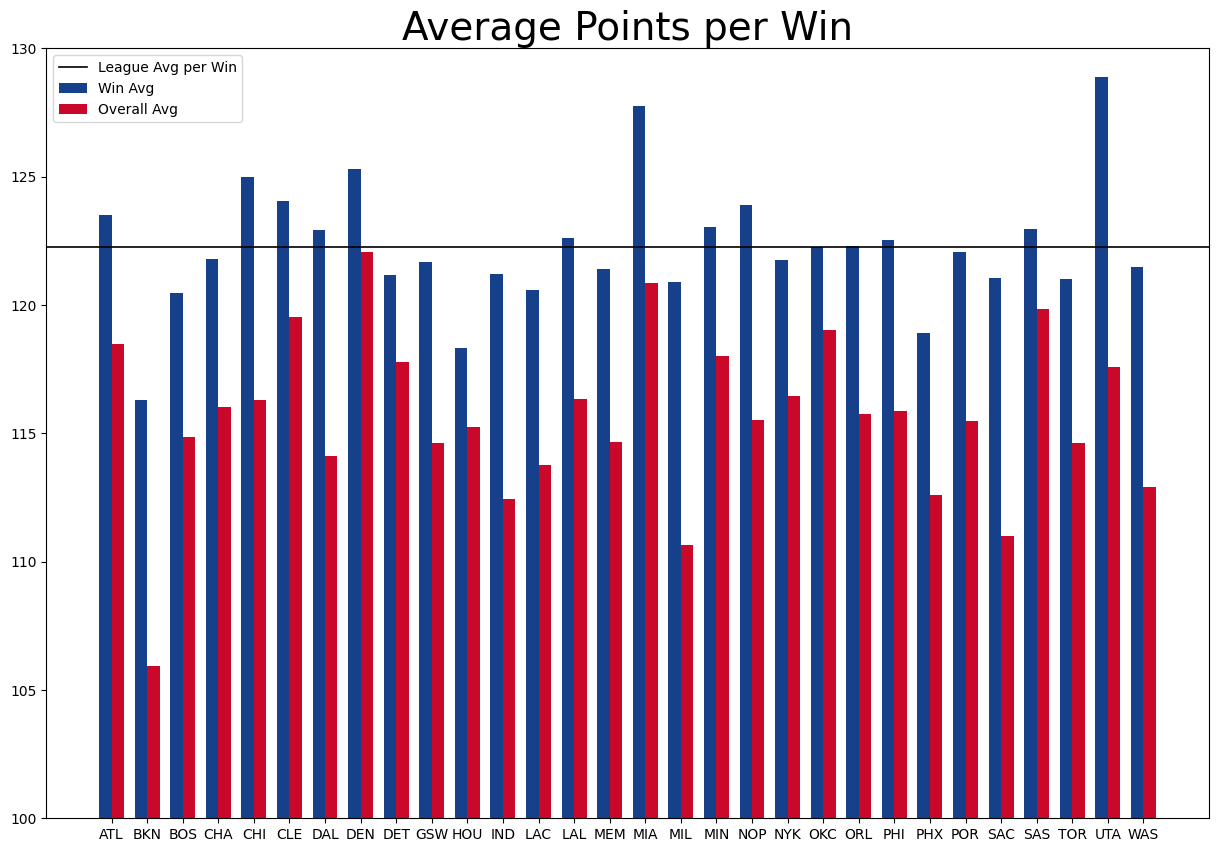

In [118]:
teams = list(overall_avg['TEAM_ABBREVIATION'])
x = np.arange(len(teams))  # Numerical locations for labels
width = 0.35  # Width of each bar

# create a figure and axis to plot a bar graph
fig, ax = plt.subplots(figsize =(15, 10))
# create and object for when plotting bar graph so that it can be looped through later. Bar graph consist of team and 'p_diff' and ronuded 2 places.
#bars_win = ax.bar(wins_agg['teams'], round(wins_agg['points'], 2), label = "Win Avg") # color = '#17408B'
#bars_ovr = ax.bar(overall_avg['TEAM_ABBREVIATION'], round(overall_avg['points'], 2), label = "Overall Avg")

bars_win = ax.bar(x - width/2, wins_agg['points'], width, label = "Win Avg", color='#17408B')
bars_ovr = ax.bar(x + width/2, overall_avg['points'], width, label = "Overall Avg", color='#C9082A')

# league_win_avg = sum(wins_agg['points'])/len(wins_agg['points'])

ax.set_ylim(100,130)
plt.title("Average Points per Win", fontsize = 28)
ax.set_xticks(x)
ax.set_xticklabels(teams)
plt.axhline(league_win_avg, color='black', linewidth=1.2, label = 'League Avg per Win') # Add a line at League Average points for wins for clarity
plt.legend()
plt.savefig('plots/points_per_win.png') # save figure off as a .png
plt.show()

In [152]:
from math import floor
from typing import Tuple
def win_pct_win_avg(team: str, points_data: pd.DataFrame, ovr_data: pd.DataFrame)->Tuple[float,int,str]:
    win_avg = points_data.loc[points_data['teams']==team, ['win_points']].values[0][0]
    avg_floor = floor(win_avg)

    games:pd.DataFrame = ovr_data.loc[(ovr_data['team'] == team) & (ovr_data['points'] >= avg_floor)]
    games_wins = games.loc[games['WL']=='W']
    num_wins = len(games_wins['WL'])
    num_games = len(games['WL'])
    pct = round(num_wins/num_games, 3)
    record = f"{num_wins}-{num_games-num_wins}"
    return pct, avg_floor, record

0.706 128 12-5
    team      gameid  opp WL  points home/away  opp_score
51   UTA  0022501181  MEM  W     147      home        101
384  UTA  0022501014  MIL  W     128      home         96
540  UTA  0022500934  GSW  W     119      home        116
607  UTA  0022500900  WAS  W     122      away        112
848  UTA  0022500786  SAC  W     121      home         93


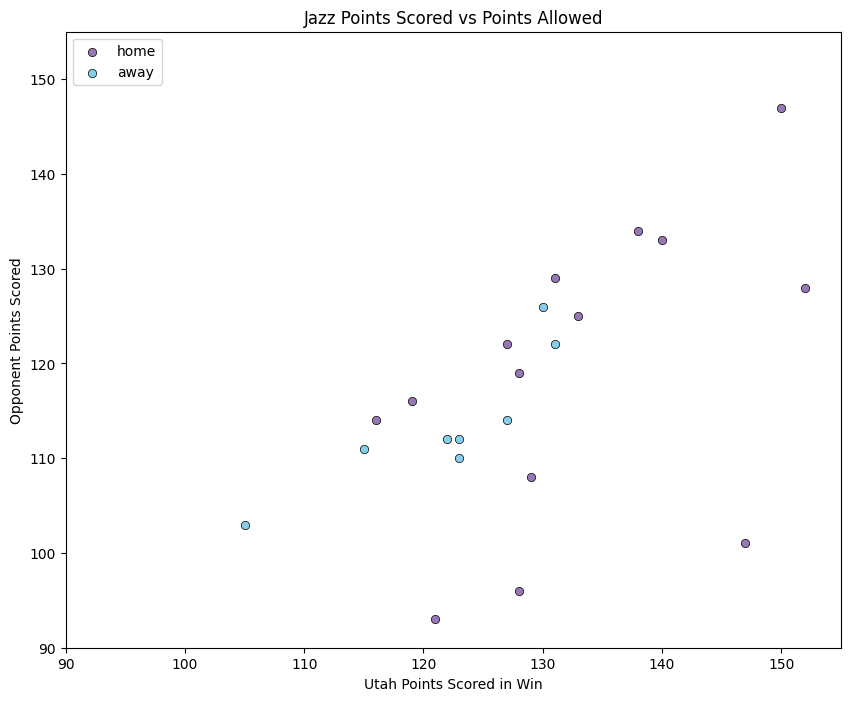

In [154]:
## FINDING WIN PERCENTAGE AT CERTAIN POINTS
pct, win_avg, record = win_pct_win_avg('UTA', points_compare, game_stats)
print(pct, win_avg, record)
## PLOTTING THE DATA

uta_wins = game_stats[(game_stats['team']== 'UTA') & (game_stats['WL'] == 'W')]
print(uta_wins.head())

mt_purp = '#9678b6'
sky_blue = '#87CEEB'
colors = [mt_purp if x == 'home' else sky_blue for x in uta_wins['home/away']]
uta_home = uta_wins[uta_wins['home/away'] == 'home']
uta_away = uta_wins[uta_wins['home/away'] == 'away']


fig2, ax2 = plt.subplots(figsize =(10, 8))
# plt.scatter(uta_wins['points'], uta_wins['opp_score'], color=colors)
scat_home = plt.scatter(uta_home['points'], uta_home['opp_score'], color=mt_purp, edgecolors='black', linewidths=0.5)
scat_away = plt.scatter(uta_away['points'], uta_away['opp_score'], color=sky_blue, edgecolors='black', linewidths=0.5)
plt.title('Jazz Points Scored vs Points Allowed')
ax2.set_xlabel("Utah Points Scored in Win")
ax2.set_ylabel("Opponent Points Scored")
ax2.set_xlim(90, 155)
ax2.set_ylim(90, 155)
plt.legend(['home', 'away'], loc='upper left')
plt.savefig('plots/uta_wins_scatter') # save figure off as a .png
plt.show()

0.688 116 11-5
    team      gameid  opp WL  points home/away  opp_score
90   BKN  0022501150  MIL  W      96      home         90
123  BKN  0022501133  WAS  W     121      home        115
228  BKN  0022501084  SAC  W     116      home         99
542  BKN  0022500932  MEM  W     126      home        115
567  BKN  0022500916  DET  W     107      away        105


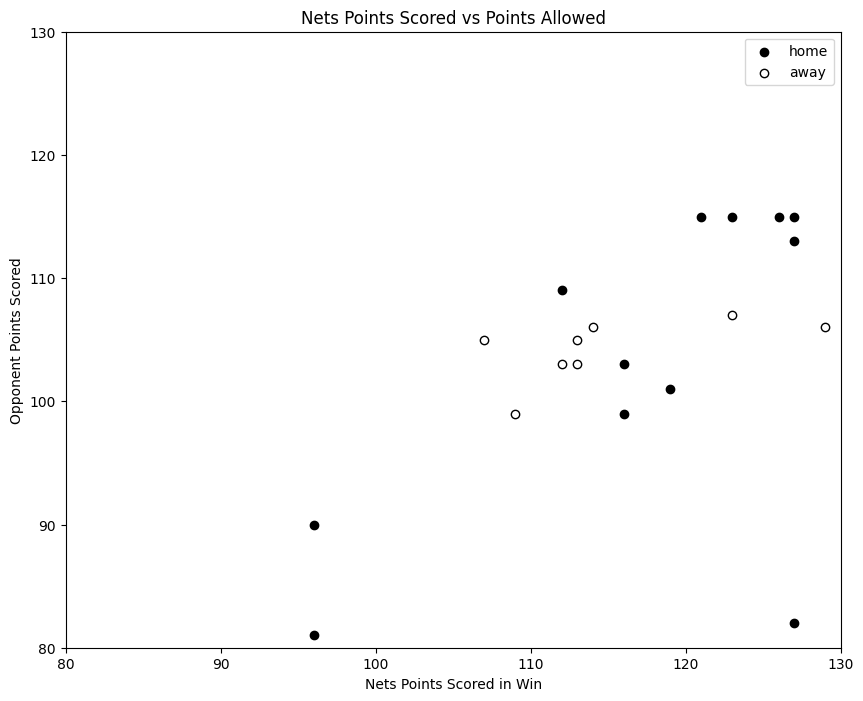

In [155]:
## FINDING WIN PERCENTAGE AT CERTAIN POINTS
pct, win_avg, record = win_pct_win_avg('BKN', points_compare, game_stats)
print(pct, win_avg, record)

## PLOTTING THE DATA
bkn_wins = game_stats[(game_stats['team']== 'BKN') & (game_stats['WL'] == 'W')]
print(bkn_wins.head())

bkn_home = bkn_wins[bkn_wins['home/away'] == 'home']
bkn_away = bkn_wins[bkn_wins['home/away'] == 'away']


fig3, ax3 = plt.subplots(figsize =(10, 8))
# plt.scatter(uta_wins['points'], uta_wins['opp_score'], color=colors)
scat_home = plt.scatter(bkn_home['points'], bkn_home['opp_score'], color='black')
scat_away = plt.scatter(bkn_away['points'], bkn_away['opp_score'], color='white', edgecolors='black')
plt.title('Nets Points Scored vs Points Allowed')
ax3.set_xlabel("Nets Points Scored in Win")
ax3.set_ylabel("Opponent Points Scored")
ax3.set_xlim(80, 130)
ax3.set_ylim(80, 130)
plt.legend(['home', 'away'])
plt.savefig('plots/bkn_wins_scatter') # save figure off as a .png
plt.show()

1.0 122 36-0
    team      gameid  opp WL  points home/away  opp_score
76   OKC  0022501163  LAC  W     128      away        110
100  OKC  0022501155  LAL  W     123      away         87
134  OKC  0022501139  UTA  W     146      home        111
167  OKC  0022501116  LAL  W     139      home         96
220  OKC  0022501097  DET  W     114      home        110


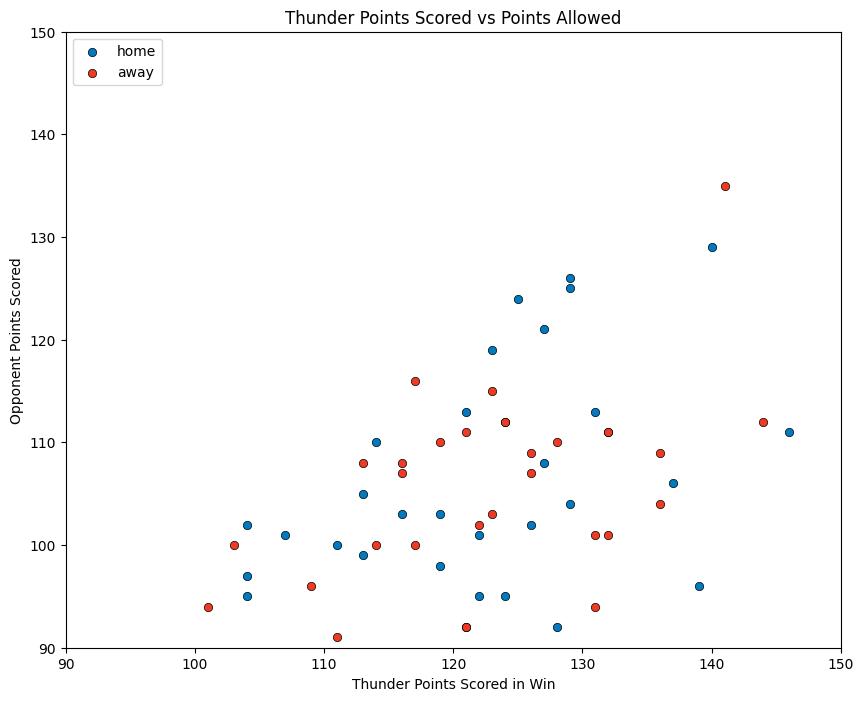

In [156]:
## FINDING WIN PERCENTAGE AT CERTAIN POINTS
pct, win_avg, record = win_pct_win_avg('OKC', points_compare, game_stats)
print(pct, win_avg, record)
## PLOTTING THE DATA

okc_wins = game_stats[(game_stats['team']== 'OKC') & (game_stats['WL'] == 'W')]
print(okc_wins.head())

okc_home = okc_wins[okc_wins['home/away'] == 'home']
okc_away = okc_wins[okc_wins['home/away'] == 'away']

thunder_blue = '#007AC1'
sunset = '#EF3B24'

fig5, ax5 = plt.subplots(figsize =(10, 8))
# plt.scatter(uta_wins['points'], uta_wins['opp_score'], color=colors)
scat_home = plt.scatter(okc_home['points'], okc_home['opp_score'], color=thunder_blue, edgecolors='black', linewidths=0.5)
scat_away = plt.scatter(okc_away['points'], okc_away['opp_score'], color=sunset, edgecolors='black', linewidths=0.5)
plt.title('Thunder Points Scored vs Points Allowed')
ax5.set_xlabel("Thunder Points Scored in Win")
ax5.set_ylabel("Opponent Points Scored")
ax5.set_xlim(90, 150)
ax5.set_ylim(90, 150)
plt.legend(['home', 'away'], loc='upper left')
plt.savefig('plots/okc_wins_scatter') # save figure off as a .png
plt.show()